# Task 2: Predict Future Stock Prices

## Objective

Build a machine learning model to predict the next day's closing stock price using historical Apple stock data downloaded from Yahoo Finance.

In [10]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print('All libraries loaded!')

All libraries loaded!


In [2]:
# Download 2 years of Apple stock data
ticker = 'AAPL'   # Change to 'TSLA' for Tesla, 'GOOGL' for Google
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


In [11]:
print("Missing Values:")
print(df.isnull().sum())

# Remove rows with missing values if any exist
df = df.dropna()

Missing Values:
Price       Ticker
Close       AAPL      0
High        AAPL      0
Low         AAPL      0
Open        AAPL      0
Volume      AAPL      0
Next_Close            0
dtype: int64


In [3]:
# Create target: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)
# Drop the last row (it has no 'next day' value)
df = df.dropna()
# Select features (input) and target (output)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (500, 5)
Target shape: (500,)


In [4]:
# 80% training data, 20% for testing
# shuffle=False is important for time-series data!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


In [5]:
# Option A: Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
# Option B: Random Forest (usually better - uncomment to use)
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useless

Mean Absolute Error: $1.72
R2 Score: 0.9345


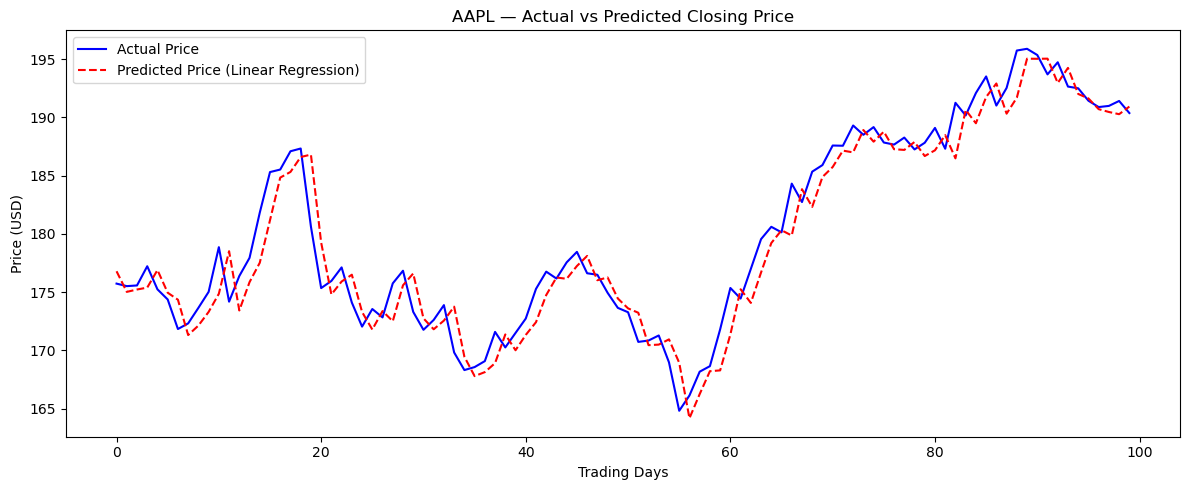

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price (Linear Regression)', color='red', linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

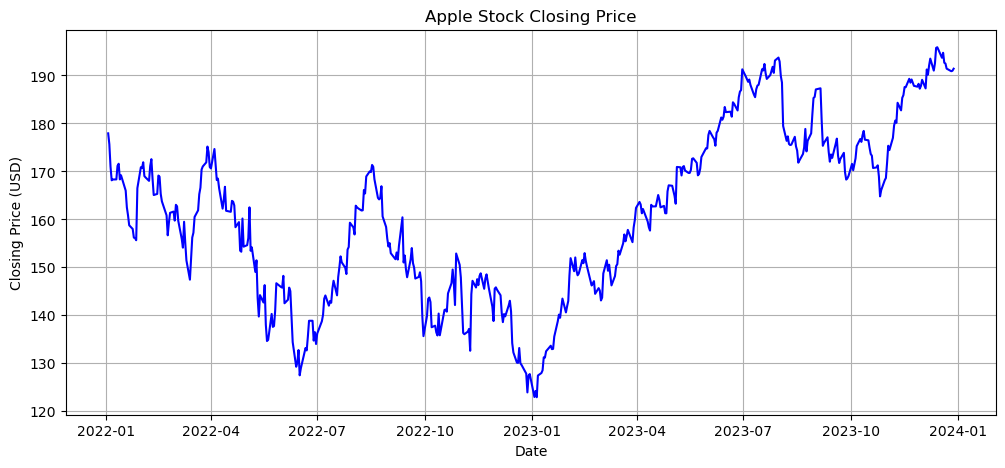

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Close"], color="blue")
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.show()

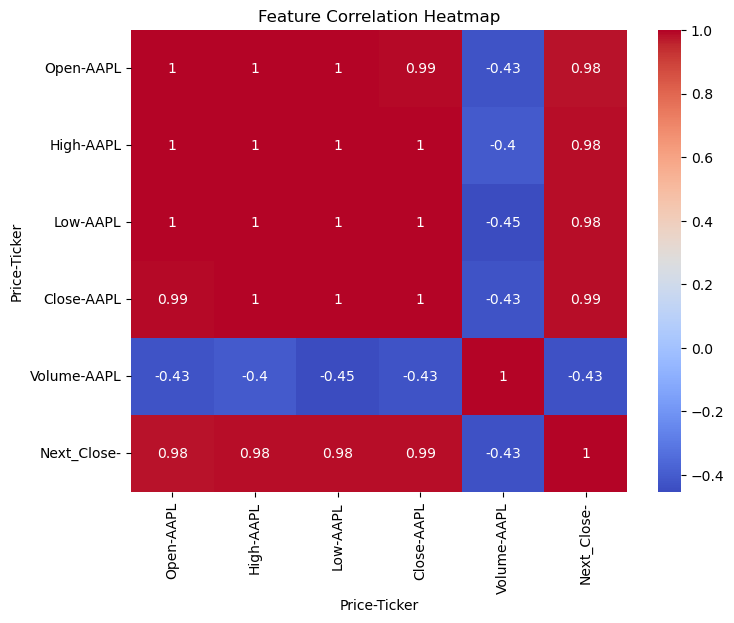

In [13]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Open","High","Low","Close","Volume","Next_Close"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Conclusion

A Linear Regression model was trained to predict the next day's closing stock price of Apple using historical stock data.

The model was evaluated using Mean Absolute Error (MAE) and R² Score. The Actual vs Predicted graph helps visualize the model's performance. This project demonstrates the complete workflow of a regression-based machine learning model for stock price prediction.